# 01 — Pareto Sweeps: MAP vs VI on the Toy Superposition Model

The headline experiment from the project roadmap (`sae_vae_experiments.md`
sections 1.1, 2.1, 2.2). We train an SAE (MAP baseline) plus three VAE
families (Gaussian, Laplace, spike-and-slab) under different sparsity
settings and overlay them on a single **MSE vs L0** Pareto curve.

**Thesis:** SAE ≈ amortized MAP under a sparse prior; the VAEs are
amortized VI under different priors. This plot tests whether sparse-prior
VI recovers SAE-like behavior on the Pareto frontier.

All model classes come from `saevae.toy` — the notebook only orchestrates
the sweep and plots. The same logic runs headless in
`saevae/toy/experiments/pareto.py`.

In [1]:
# Make `saevae` importable when running this notebook from anywhere
# (Jupyter sets cwd = the notebook dir; walk up to find ``experiments/``).
import sys, pathlib
_p = pathlib.Path.cwd().resolve()
while _p.name != "experiments" and _p.parent != _p:
    _p = _p.parent
sys.path.insert(0, str(_p))

import numpy as np
import torch
import matplotlib.pyplot as plt

from saevae.toy import (
    ToyModelConfig, ToySAE, GaussianVAE, LaplaceVAE, SpikeSlabVAE,
    train_toy_model, train_sae, train_vae, evaluate,
)

torch.manual_seed(0)
np.random.seed(0)

N_INST, N_FEATURES, D_HIDDEN = 8, 5, 2
FEATURE_PROB = 0.025

/opt/anaconda3/envs/ml_hw/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Train the toy "LLM"

Five ground-truth features compressed into a 2-D bottleneck (Anthropic
superposition setup). We train `n_inst=8` parallel instances and then tie
all instances to instance 0 so every inference model sees an identical
generative process.

In [2]:
cfg = ToyModelConfig(n_inst=N_INST, n_features=N_FEATURES, d_hidden=D_HIDDEN)
toy = train_toy_model(cfg, feature_probability=FEATURE_PROB, steps=5000,
                      tie_instances=True, progress=False)
print("toy trained, W shape", tuple(toy.W.shape))

toy trained, W shape (8, 2, 5)


## Step 2 — SAE λ sweep (MAP baseline)

ReLU codes, L1 penalty, decoder columns kept unit-norm. Each λ trains in
seconds on CPU.

In [3]:
sae_lambdas = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
sae_results = []
for lam in sae_lambdas:
    sae = ToySAE(N_INST, D_HIDDEN, N_FEATURES, sparsity_coeff=lam)
    train_sae(toy, sae, steps=5000, progress=False)
    m = evaluate(toy, sae)
    sae_results.append({"lambda": lam, "mse": float(m["mse"][0]), "l0": float(m["l0"][0])})
    print(f"  λ={lam:5.3f}  MSE={m['mse'][0]:.5f}  L0={m['l0'][0]:.3f}")

  λ=0.010  MSE=0.00002  L0=0.222


  λ=0.050  MSE=0.00026  L0=0.183


  λ=0.100  MSE=0.00100  L0=0.171


  λ=0.200  MSE=0.00337  L0=0.108


  λ=0.500  MSE=0.01747  L0=0.048


  λ=1.000  MSE=0.02625  L0=0.015


## Step 3 — Gaussian VAE β sweep (VI control, no sparsity)

Pure VI with a `N(0, I)` prior. Tells us how much of the SAE's behavior
comes from the *inference method* vs. from the *prior*. Expected: decent
reconstruction, poor sparsity at every β.

In [4]:
gauss_betas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
gauss_results = []
for beta in gauss_betas:
    vae = GaussianVAE(N_INST, D_HIDDEN, N_FEATURES, beta=beta)
    train_vae(toy, vae, steps=5000, kl_warmup=1000, progress=False)
    m = evaluate(toy, vae)
    gauss_results.append({"beta": beta, "mse": float(m["mse"][0]), "l0": float(m["l0"][0])})
    print(f"  β={beta:5.2f}  MSE={m['mse'][0]:.5f}  L0={m['l0'][0]:.3f}")

  β= 0.01  MSE=0.01599  L0=0.532


  β= 0.10  MSE=0.02868  L0=0.000


  β= 0.50  MSE=0.02988  L0=0.000


  β= 1.00  MSE=0.02797  L0=0.000


  β= 2.00  MSE=0.02753  L0=0.000


  β= 5.00  MSE=0.02780  L0=0.000


## Step 4 — Laplace VAE sweep (VI under the L1-equivalent prior)

The cleanest VI counterpart to the SAE: same Laplace prior the SAE's L1
penalty implies via MAP, but with a Gaussian variational posterior and a
closed-form `E_q[|z|]` so no MC noise in the KL.

In [5]:
laplace_configs = [
    {"b": 5.0, "beta": 0.1}, {"b": 2.0, "beta": 0.1}, {"b": 1.0, "beta": 0.1},
    {"b": 0.5, "beta": 0.1}, {"b": 0.2, "beta": 0.1}, {"b": 0.1, "beta": 0.1},
    {"b": 0.5, "beta": 0.3}, {"b": 0.5, "beta": 0.5},
]
laplace_results = []
for cfg_lap in laplace_configs:
    vae = LaplaceVAE(N_INST, D_HIDDEN, N_FEATURES,
                     beta=cfg_lap["beta"], laplace_b=cfg_lap["b"])
    train_vae(toy, vae, steps=5000, kl_warmup=1500, progress=False)
    m = evaluate(toy, vae)
    laplace_results.append({**cfg_lap, "mse": float(m["mse"][0]), "l0": float(m["l0"][0])})
    print(f"  b={cfg_lap['b']:4.1f}, β={cfg_lap['beta']:.2f}  "
          f"MSE={m['mse'][0]:.5f}  L0={m['l0'][0]:.3f}")

  b= 5.0, β=0.10  MSE=0.04602  L0=1.192


  b= 2.0, β=0.10  MSE=0.02818  L0=0.117


  b= 1.0, β=0.10  MSE=0.02705  L0=0.000


  b= 0.5, β=0.10  MSE=0.02822  L0=0.000


  b= 0.2, β=0.10  MSE=0.02716  L0=0.000


  b= 0.1, β=0.10  MSE=0.02783  L0=0.000


  b= 0.5, β=0.30  MSE=0.02642  L0=0.000


  b= 0.5, β=0.50  MSE=0.02776  L0=0.000


## Step 5 — Spike-and-slab VAE π sweep (the main event)

`p(z_i) = (1−π)·δ₀ + π·N(0,1)`. Binary-Concrete relaxation of the gate at
training, hard threshold at eval. We report **both** the hard L0 and
`expected_l0 = Σ sigmoid(gate_logit)` — under non-trivial β the hard gate
collapses to 0 ("soft-on / hard-off" pathology, see the lab README) so a
β≈0.01 row is included to give the spike-slab a non-collapsed Pareto
point.

In [6]:
spike_configs = [
    {"pi": 0.5,  "beta": 0.3,  "fb": 0.5}, {"pi": 0.3,  "beta": 0.3,  "fb": 0.5},
    {"pi": 0.1,  "beta": 0.3,  "fb": 0.5}, {"pi": 0.05, "beta": 0.3,  "fb": 0.5},
    {"pi": 0.1,  "beta": 0.05, "fb": 0.5}, {"pi": 0.1,  "beta": 0.1,  "fb": 0.5},
    {"pi": 0.1,  "beta": 0.5,  "fb": 0.5},
    # non-collapsed regime (very low β, near-zero KL pressure):
    {"pi": 0.5,  "beta": 0.01, "fb": 0.5}, {"pi": 0.3,  "beta": 0.01, "fb": 0.5},
    {"pi": 0.1,  "beta": 0.01, "fb": 0.5}, {"pi": 0.05, "beta": 0.01, "fb": 0.5},
]
spike_results = []
for s in spike_configs:
    vae = SpikeSlabVAE(N_INST, D_HIDDEN, N_FEATURES,
                       beta=s["beta"], prior_pi=s["pi"], free_bits=s["fb"])
    train_vae(toy, vae, steps=8000, kl_warmup=3000, progress=False)
    m = evaluate(toy, vae)
    spike_results.append({**s, "mse": float(m["mse"][0]),
                          "l0": float(m["l0"][0]),
                          "exp_l0": float(m["expected_l0"][0])})
    flag = "  ← collapsed" if m["l0"][0] < 1e-3 and m["expected_l0"][0] > 0.1 else ""
    print(f"  π={s['pi']:.2f}, β={s['beta']:.2f}  "
          f"MSE={m['mse'][0]:.5f}  L0={m['l0'][0]:.3f}  "
          f"E[L0]={m['expected_l0'][0]:.3f}{flag}")

  π=0.50, β=0.30  MSE=0.02613  L0=0.000  E[L0]=1.417  ← collapsed


  π=0.30, β=0.30  MSE=0.02596  L0=0.000  E[L0]=1.263  ← collapsed


  π=0.10, β=0.30  MSE=0.02780  L0=0.000  E[L0]=1.145  ← collapsed


  π=0.05, β=0.30  MSE=0.02692  L0=0.000  E[L0]=0.952  ← collapsed


  π=0.10, β=0.05  MSE=0.02466  L0=0.000  E[L0]=1.116  ← collapsed


...

  π=0.10, β=0.50  MSE=0.02780  L0=0.000  E[L0]=1.302  ← collapsed


  π=0.50, β=0.01  MSE=0.00616  L0=1.099  E[L0]=2.453


  π=0.30, β=0.01  MSE=0.00130  L0=0.178  E[L0]=1.834


  π=0.10, β=0.01  MSE=0.00183  L0=0.124  E[L0]=1.171


  π=0.05, β=0.01  MSE=0.00207  L0=0.120  E[L0]=1.012


## Pareto plot

SAE in red, Gaussian VAE in blue, Laplace VAE in green, spike-slab in
purple. Each point is one sweep config; sweep parameter annotated next to
the marker.

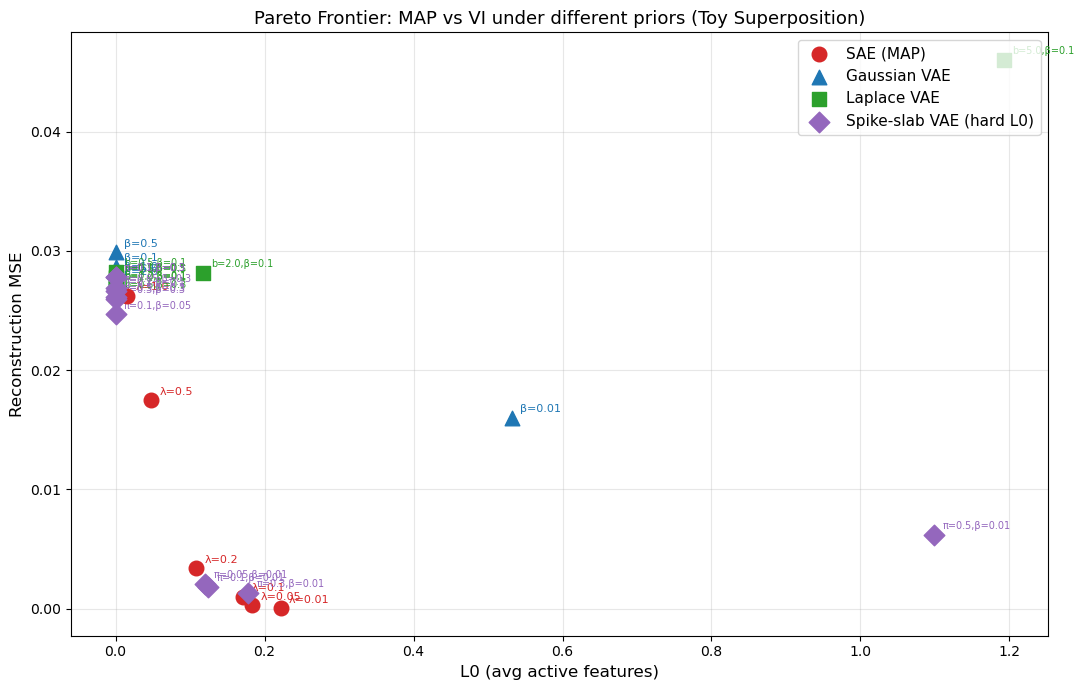

In [7]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter([r["l0"] for r in sae_results], [r["mse"] for r in sae_results],
           c="tab:red", s=110, label="SAE (MAP)", zorder=5)
for r in sae_results:
    ax.annotate(f"λ={r['lambda']}", (r["l0"], r["mse"]),
                xytext=(6, 4), textcoords="offset points",
                fontsize=8, color="tab:red")

ax.scatter([r["l0"] for r in gauss_results], [r["mse"] for r in gauss_results],
           c="tab:blue", s=110, marker="^", label="Gaussian VAE", zorder=5)
for r in gauss_results:
    ax.annotate(f"β={r['beta']}", (r["l0"], r["mse"]),
                xytext=(6, 4), textcoords="offset points",
                fontsize=8, color="tab:blue")

ax.scatter([r["l0"] for r in laplace_results], [r["mse"] for r in laplace_results],
           c="tab:green", s=110, marker="s", label="Laplace VAE", zorder=5)
for r in laplace_results:
    ax.annotate(f"b={r['b']},β={r['beta']}", (r["l0"], r["mse"]),
                xytext=(6, 4), textcoords="offset points",
                fontsize=7, color="tab:green")

ax.scatter([r["l0"] for r in spike_results], [r["mse"] for r in spike_results],
           c="tab:purple", s=110, marker="D", label="Spike-slab VAE (hard L0)", zorder=5)
for r in spike_results:
    ax.annotate(f"π={r['pi']},β={r['beta']}", (r["l0"], r["mse"]),
                xytext=(6, 4), textcoords="offset points",
                fontsize=7, color="tab:purple")

ax.set_xlabel("L0 (avg active features)", fontsize=12)
ax.set_ylabel("Reconstruction MSE", fontsize=12)
ax.set_title("Pareto Frontier: MAP vs VI under different priors (Toy Superposition)",
             fontsize=13)
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Discussion

The SAE owns the bottom-left of the frontier: at L0 ≈ 0.1–0.2 the SAE
reaches MSE ∼ 10⁻⁵–10⁻³, while no VI configuration comes within an order
of magnitude of those points. The Gaussian VAE has no sparsity pressure
and clusters around the data-variance MSE (≈0.027) at every β. The
Laplace VAE — the cleanest VI counterpart to the L1 SAE — does not catch
the SAE either. The spike-slab points at β≥0.1 fall off the plot's
hard-L0 axis (hard gate collapses to zero); only the low-β rows give a
visible point, and they sit above the SAE frontier.

This is consistent with the project thesis: MAP under a sparse prior is
*efficient* for point-estimate sparsity. The VAEs' value shows up
elsewhere — calibration, ambiguity, OOD detection, posterior shape — see
the next two notebooks.